In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

In [5]:
warnings.filterwarnings("ignore")

# Visualizing Hypertension Vs Activity Level

In [ ]:
# --- Load data ---
df_demo =  pd.read_csv("../data/demographic_data.csv") 
df_pa = pd.read_csv("../data/Quest_physical_activity.csv")
df_merged_hypertensive =  pd.read_csv("../data/merged_demo_hypertensive_bmi_data.csv")
df_merged_hypertensive = df_merged_hypertensive[['Participant_ID', 'Hypertensive','BMI','Abdominal_Obesity']]

# --- Merge on Participant_ID ---

df_pa = df_pa.rename(columns={'seqn_no': 'Participant_ID'})
df_merged_data = df_demo.merge(df_pa, on="Participant_ID", how ='right')
df_merged = df_merged_data.merge(df_merged_hypertensive,on="Participant_ID", how= 'inner')

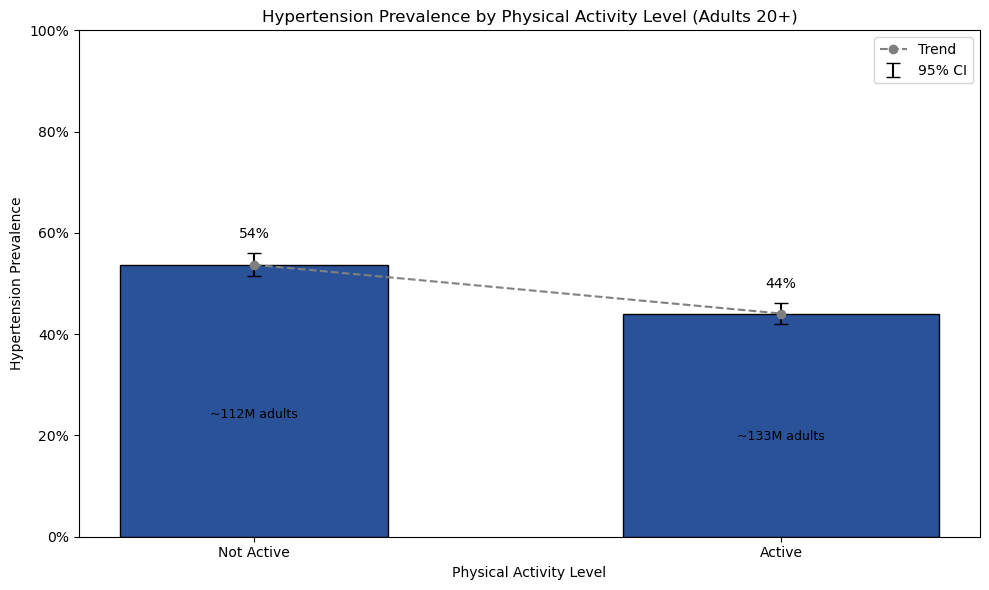

In [ ]:
# --- Filter: Adults (20+), valid hypertension, physical activity, and positive weights ---
df_filtered = df_merged[
    (df_merged['Age_Years'] >= 20) &
    df_merged['Hypertensive'].notna() &
    df_merged['activity_level'].notna() &
    (df_merged['Exam_Weight'] > 0)
]

# --- Normalize activity_level labels ---
df_filtered['activity_level'] = df_filtered['activity_level'].str.strip().str.lower()
df_filtered['activity_level'] = df_filtered['activity_level'].replace({
    'not active': 'not_active',
    'active': 'active'
})

# --- Define allowed categories ---
activity_order = ['not_active', 'active']
df_filtered = df_filtered[df_filtered['activity_level'].isin(activity_order)]

# --- Weighted CI Function ---
def compute_weighted_ci(group):
    weights = group['Exam_Weight']
    p = np.average(group['Hypertensive'], weights=weights)
    weight_sum = weights.sum()
    weight_sq_sum = (weights**2).sum()
    n_eff = (weight_sum ** 2) / weight_sq_sum
    se = np.sqrt(p * (1 - p) / n_eff)
    ci_lower = max(0, p - 1.96 * se)
    ci_upper = min(1, p + 1.96 * se)
    return pd.Series({
        'Weighted_Hypertension_Prevalence': p,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Weighted_Population': weight_sum
    })

# --- Compute stats by activity level ---
pa_results = df_filtered.groupby("activity_level").apply(compute_weighted_ci).reset_index()

# --- Order activity levels ---
pa_results['activity_level'] = pd.Categorical(pa_results['activity_level'], categories=activity_order, ordered=True)
pa_results = pa_results.sort_values('activity_level').reset_index(drop=True)

# --- Normalize population for bar width ---
pa_results['Norm_Pop'] = pa_results['Weighted_Population'] / pa_results['Weighted_Population'].max()

# --- Plotting ---
plt.figure(figsize=(10, 6))
bar_positions = np.arange(len(pa_results))


bars = plt.bar(
    bar_positions,
    pa_results['Weighted_Hypertension_Prevalence'],
    width=pa_results['Norm_Pop'] * 0.6,
    color =  "#2A5298",
    edgecolor='black'
)

# --- Error bars ---
plt.errorbar(
    x=bar_positions,
    y=pa_results['Weighted_Hypertension_Prevalence'],
    yerr=[
        pa_results['Weighted_Hypertension_Prevalence'] - pa_results['CI_Lower'],
        pa_results['CI_Upper'] - pa_results['Weighted_Hypertension_Prevalence']
    ],
    fmt='none', ecolor='black', capsize=5, label="95% CI"
)

# --- Labels ---
for i, row in pa_results.iterrows():
    percent = int(round(row['Weighted_Hypertension_Prevalence'] * 100))
    pop_m = int(round(row['Weighted_Population'] / 1_000_000))

    plt.text(i, row['Weighted_Hypertension_Prevalence'] * 0.45,
             f"~{pop_m}M adults", ha='center', va='center', fontsize=9)

    plt.text(i, row['CI_Upper'] + 0.03,
             f"{percent}%", ha='center', fontsize=10)

# --- Trend line ---
plt.plot(bar_positions, pa_results['Weighted_Hypertension_Prevalence'],marker='o', linestyle='--', color='gray', label='Trend')


# --- Aesthetics ---
plt.xticks(bar_positions, pa_results['activity_level'].str.replace('_', ' ').str.title())
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.title("Hypertension Prevalence by Physical Activity Level (Adults 20+)")
plt.xlabel("Physical Activity Level")
plt.ylabel("Hypertension Prevalence")
plt.ylim(0, 1)
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()



# Visualizing Hypertension Vs Activity Level by Gender

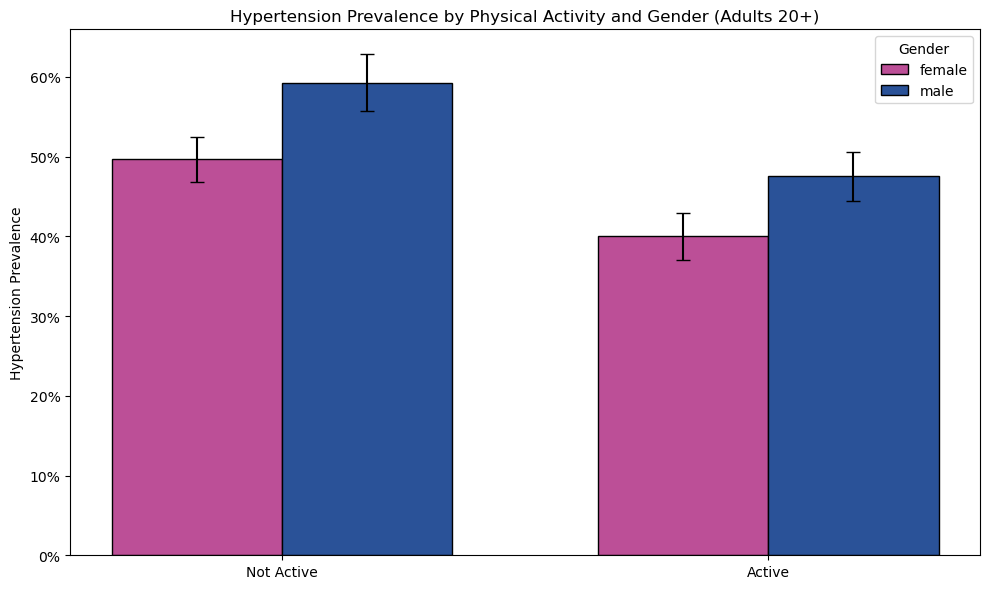

In [17]:
# --- Group and calculate weighted hypertension prevalence by activity level and gender ---
gender_pa_results = df_filtered.groupby(['activity_level', 'Gender']).apply(compute_weighted_ci).reset_index()

# Order activity levels
activity_order = ['not_active', 'active']
gender_pa_results['activity_level'] = pd.Categorical(gender_pa_results['activity_level'], categories=activity_order, ordered=True)
gender_pa_results = gender_pa_results.sort_values(['activity_level', 'Gender'])

# Setup
grouped = gender_pa_results
activity_levels = grouped['activity_level'].unique()
genders = grouped['Gender'].unique()

x = np.arange(len(activity_levels))  # Base x positions
width = 0.35  # Width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for each gender
for idx, gender in enumerate(genders):
    subset = grouped[grouped['Gender'] == gender]
    
    # Bar positions are offset
    bar_positions = x + (idx - 0.5) * width
    
    ax.bar(
        bar_positions,
        subset['Weighted_Hypertension_Prevalence'],
        width=width,
        label=gender,
        color=["#BC4F97","#2A5298"][idx],
        edgecolor='black',
        yerr=[
            subset['Weighted_Hypertension_Prevalence'] - subset['CI_Lower'],
            subset['CI_Upper'] - subset['Weighted_Hypertension_Prevalence']
        ],
        capsize=5
    )

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels([lvl.replace("_", " ").title() for lvl in activity_levels])
ax.set_ylabel("Hypertension Prevalence")
ax.set_title("Hypertension Prevalence by Physical Activity and Gender (Adults 20+)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(title="Gender")
plt.tight_layout()
plt.show()

# Visualizing Hypertension Vs Activity Level considering the group Ethinicity

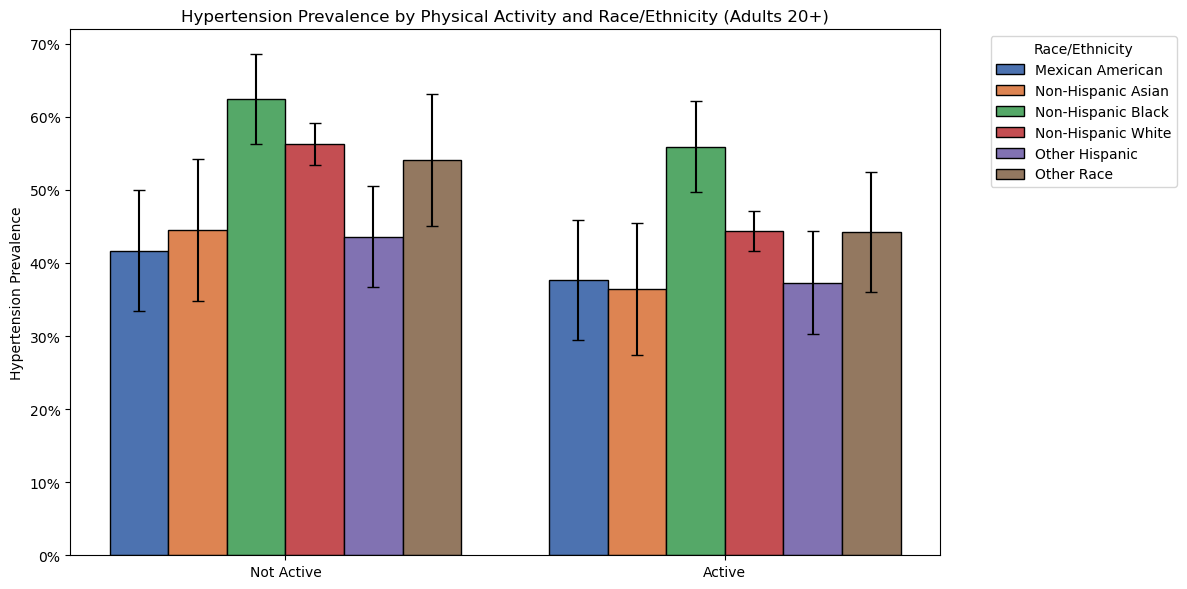

In [ ]:
# --- Map Race_Ethnicity codes to labels ---
ethnicity_map = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other Race"
}

df_filtered['Race_Ethnicity'] = df_filtered['Race_Ethnicity'].map(ethnicity_map)

# --- Filter out rows with unmapped (NaN) values ---
df_filtered = df_filtered[df_filtered['Race_Ethnicity'].notna()]

# --- Group and calculate weighted prevalence + CIs ---
grouped = df_filtered.groupby(['activity_level', 'Race_Ethnicity']).apply(compute_weighted_ci).reset_index()

# --- Define activity level order ---
activity_order = ['not_active', 'active']
grouped['activity_level'] = pd.Categorical(grouped['activity_level'], categories=activity_order, ordered=True)

# --- Pivot for plotting ---
pivot = grouped.pivot_table(index='activity_level', columns='Race_Ethnicity', values='Weighted_Hypertension_Prevalence').reindex(index=activity_order)
ci_lower = grouped.pivot_table(index='activity_level', columns='Race_Ethnicity', values='CI_Lower').reindex(index=activity_order)
ci_upper = grouped.pivot_table(index='activity_level', columns='Race_Ethnicity', values='CI_Upper').reindex(index=activity_order)

# --- Plot setup ---
activity_levels = pivot.index.tolist()
ethnicities = pivot.columns.tolist()
x = np.arange(len(activity_levels))
width = 0.8 / len(ethnicities)

# --- Custom professional color palette ---
custom_colors = [
    "#4C72B0",  # Blue
    "#DD8452",  # Orange
    "#55A868",  # Green
    "#C44E52",  # Red
    "#8172B2",  # Purple
    "#937860"   # Brown
]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6))

for idx, ethnicity in enumerate(ethnicities):
    y = pivot[ethnicity]
    lower = y - ci_lower[ethnicity]
    upper = ci_upper[ethnicity] - y
    bar_positions = x + (idx - len(ethnicities)/2) * width + width/2

    ax.bar(
        bar_positions,
        y,
        width=width,
        label=ethnicity,
        color=custom_colors[idx % len(custom_colors)],
        edgecolor='black',
        yerr=[lower, upper],
        capsize=4
    )

# --- Formatting ---
ax.set_xticks(x)
ax.set_xticklabels([lvl.replace("_", " ").title() for lvl in activity_levels])
ax.set_ylabel("Hypertension Prevalence")
ax.set_title("Hypertension Prevalence by Physical Activity and Race/Ethnicity (Adults 20+)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(title="Race/Ethnicity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Visualizing Hypertension Vs Activity Level  by Age Group & Gender

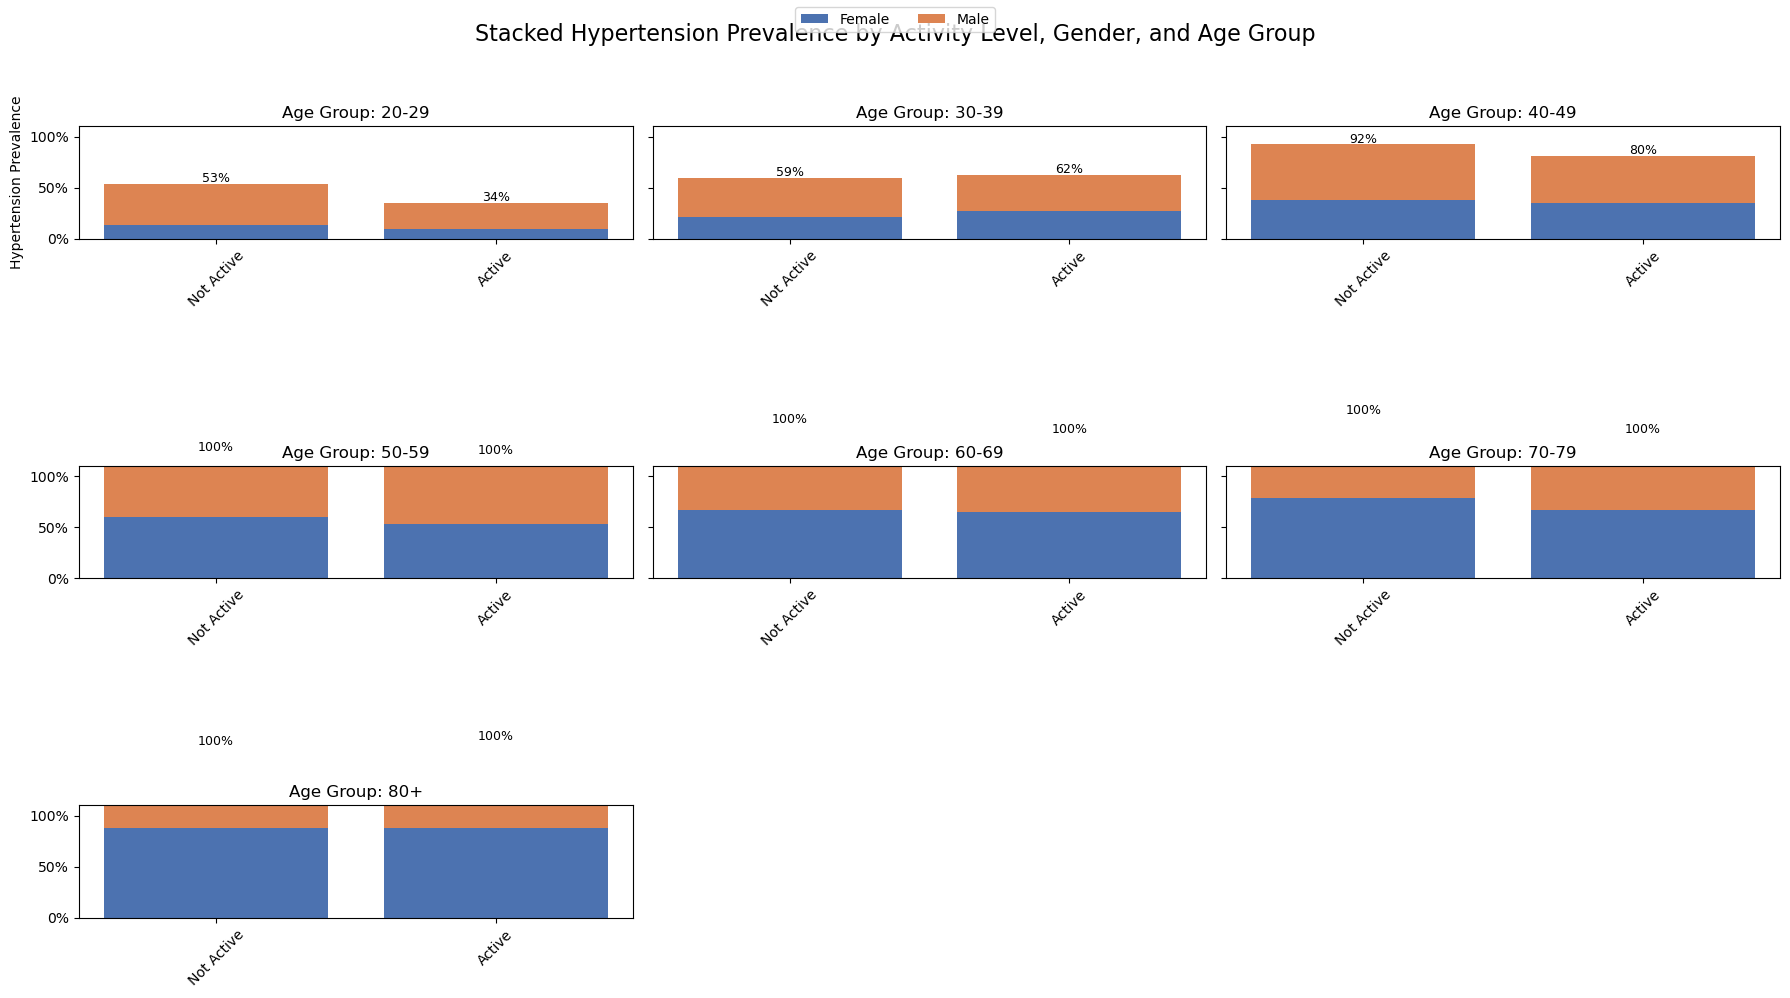

In [9]:
# First, bin age
age_bins = [20, 30, 40, 50, 60, 70, 80, np.inf]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df_filtered['Age_Group'] = pd.cut(df_filtered['Age_Years'], bins=age_bins, labels=age_labels, right=False)

# Compute weighted stats by activity_level, gender, age group
grouped = df_filtered.groupby(['Age_Group', 'activity_level', 'Gender','Race_Ethnicity']).apply(compute_weighted_ci).reset_index()

# --- Ensure Gender values are lowercase for consistent pivoting ---
grouped['Gender'] = grouped['Gender'].str.lower()

# --- Pivot setup ---
pivot_df = grouped.pivot_table(
    index=['Age_Group', 'activity_level'],
    columns='Gender',
    values='Weighted_Hypertension_Prevalence',
    fill_value=0
).reset_index()

# --- Order activity levels ---
activity_order = ['not_active', 'active']
pivot_df['activity_level'] = pd.Categorical(pivot_df['activity_level'], categories=activity_order, ordered=True)
pivot_df = pivot_df.sort_values(['Age_Group', 'activity_level'])

# --- Extract unique age groups ---
age_groups = pivot_df['Age_Group'].unique()
n_groups = len(age_groups)

# --- Layout: split into 2 rows ---
ncols = 3
nrows = int(np.ceil(n_groups / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for ax, age in zip(axes, age_groups):
    df_age = pivot_df[pivot_df['Age_Group'] == age]
    x = np.arange(len(df_age))

    female_vals = df_age.get('female', pd.Series([0] * len(df_age)))
    male_vals = df_age.get('male', pd.Series([0] * len(df_age)))

    # Plot bars
    ax.bar(x, female_vals, label='Female', color='#4C72B0')
    ax.bar(x, male_vals, bottom=female_vals, label='Male', color='#DD8452')

    # Axis settings
    ax.set_xticks(x)
    ax.set_xticklabels(df_age['activity_level'].str.replace('_', ' ').str.title(), rotation=45)
    ax.set_title(f"Age Group: {age}")
    ax.set_ylim(0, 1.1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # % Labels
    for i in range(len(df_age)):
        total = female_vals.iloc[i] + male_vals.iloc[i]
        capped_total = min(total, 1.0)
        ax.text(x[i], total + 0.02, f"{int(capped_total * 100)}%", ha='center', fontsize=9)

# --- Hide unused axes ---
for ax in axes[n_groups:]:
    ax.set_visible(False)

# --- Title and legend ---
fig.suptitle("Stacked Hypertension Prevalence by Activity Level, Gender, and Age Group", fontsize=16)
axes[0].set_ylabel("Hypertension Prevalence")

# Global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Visualizing Hypertension Vs Activity Level  by Age Group, Gender & Ethinicity

In [ ]:

# Assume `compute_weighted_ci` returns something like:
# pd.Series({'Weighted_Hypertension_Prevalence': ..., 'lower_ci': ..., 'upper_ci': ...})

grouped = df_filtered.groupby(['Age_Group', 'activity_level', 'Gender', 'Race_Ethnicity']) \
                     .apply(compute_weighted_ci).reset_index()

df_norm = grouped.copy()

# Normalize within (Age_Group, activity_level, Ethnicity)
df_norm['total'] = df_norm.groupby(['Age_Group', 'activity_level', 'Race_Ethnicity'])['Weighted_Hypertension_Prevalence'].transform('sum')
df_norm['Normalized_Prevalence'] = df_norm['Weighted_Hypertension_Prevalence'] / df_norm['total']


grouped['total'] = grouped.groupby(['Age_Group', 'activity_level', 'Race_Ethnicity'])['Weighted_Hypertension_Prevalence'].transform('sum')
grouped['Normalized_Prevalence'] = grouped['Weighted_Hypertension_Prevalence'] / grouped['total']

# Sort activity levels
activity_order = ['inactive', 'not_active', 'somewhat active', 'active']
grouped['activity_level'] = pd.Categorical(grouped['activity_level'], categories=activity_order, ordered=True)

# Optional: Sort age group
grouped['Age_Group'] = pd.Categorical(grouped['Age_Group'], categories=age_labels, ordered=True)

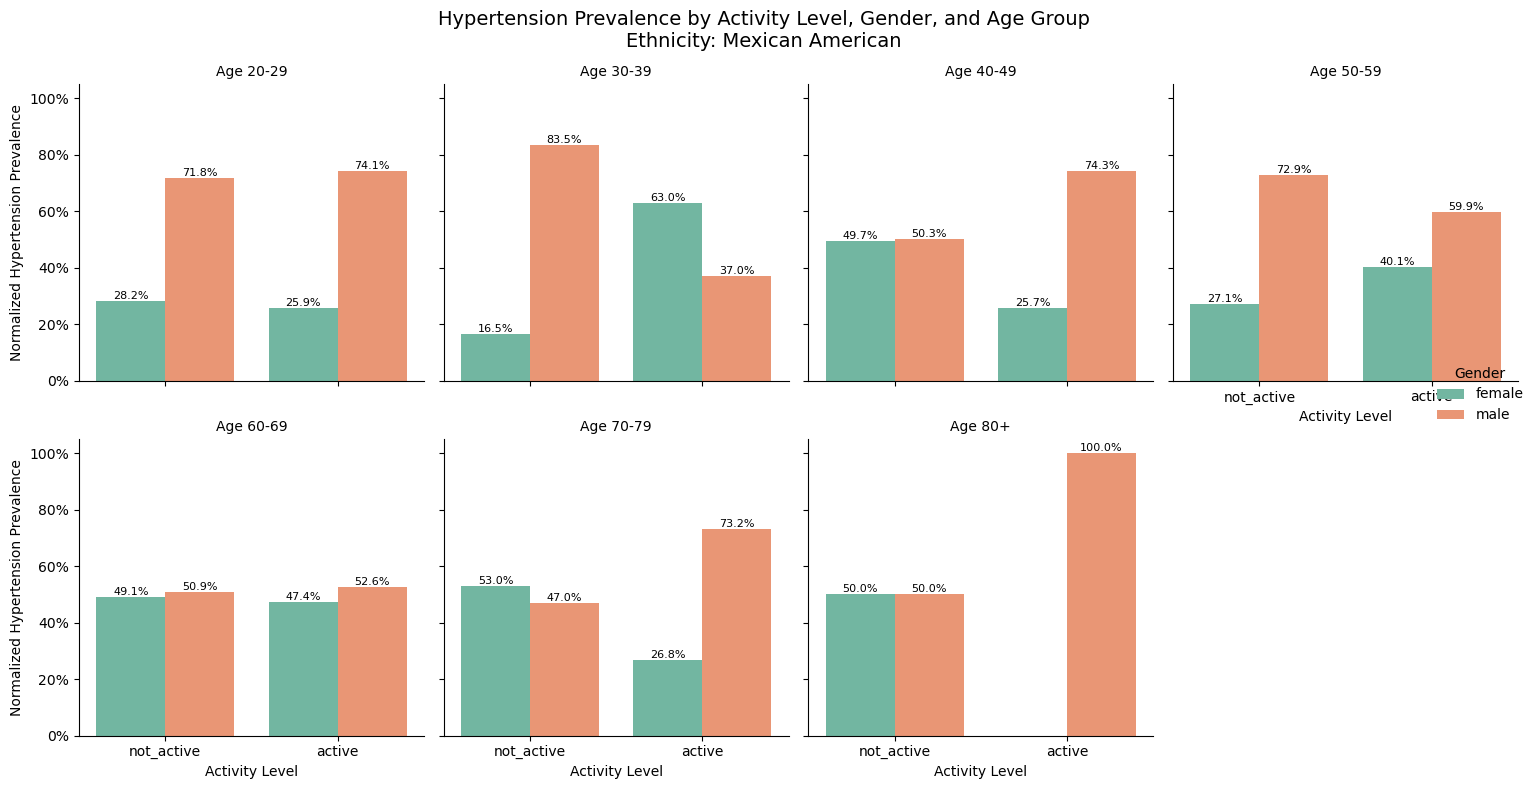

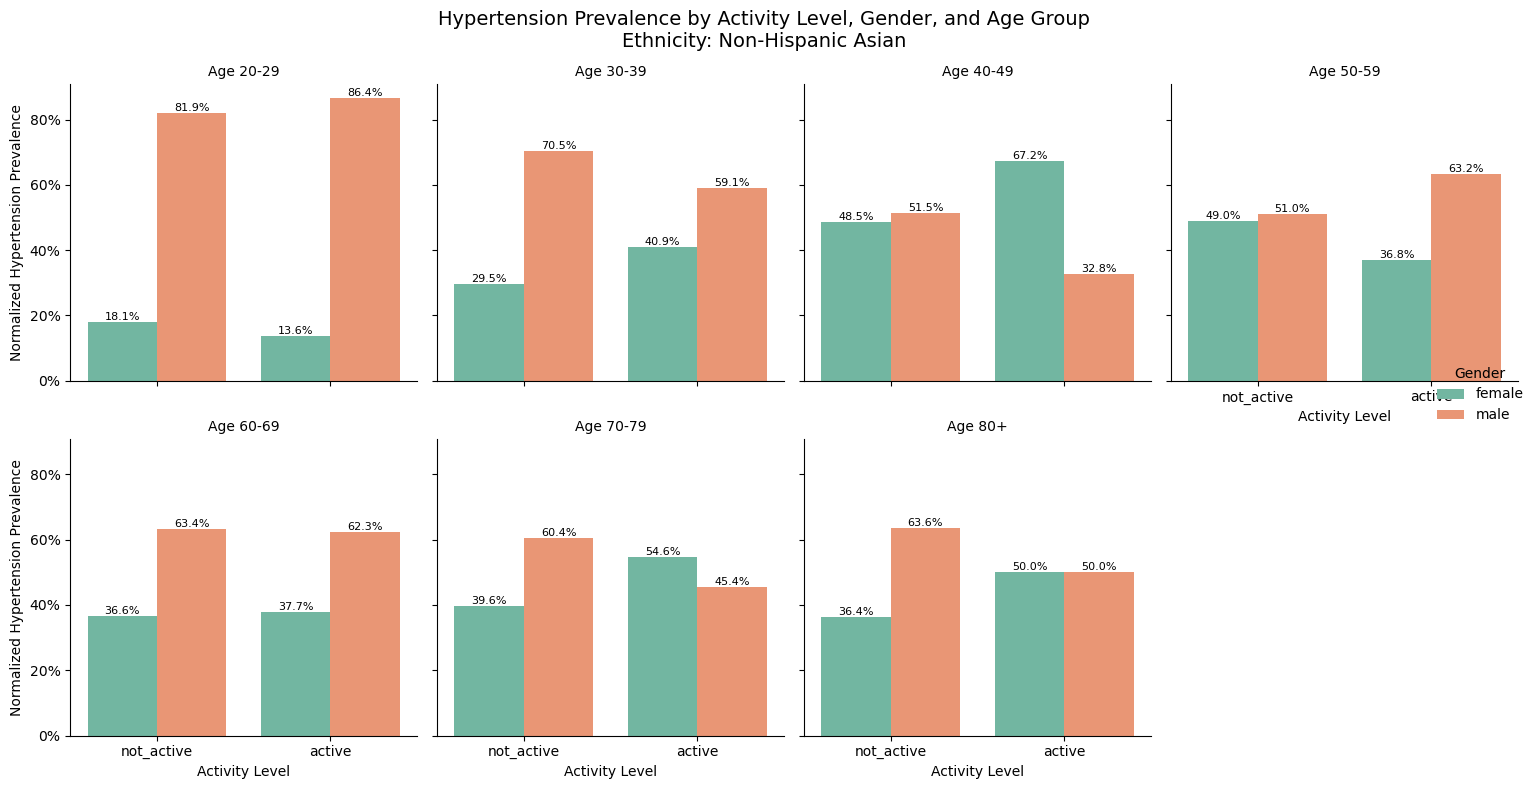

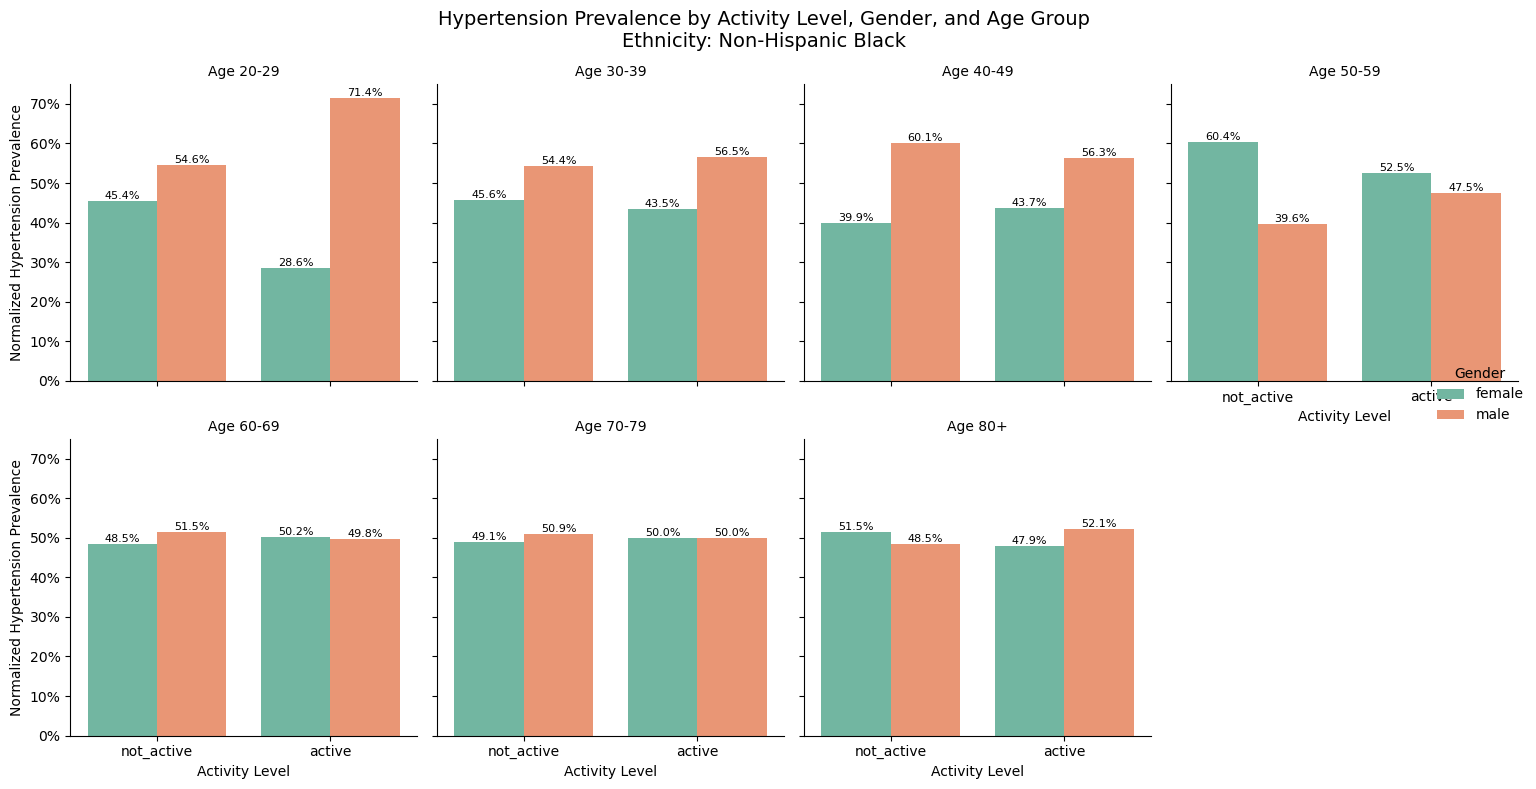

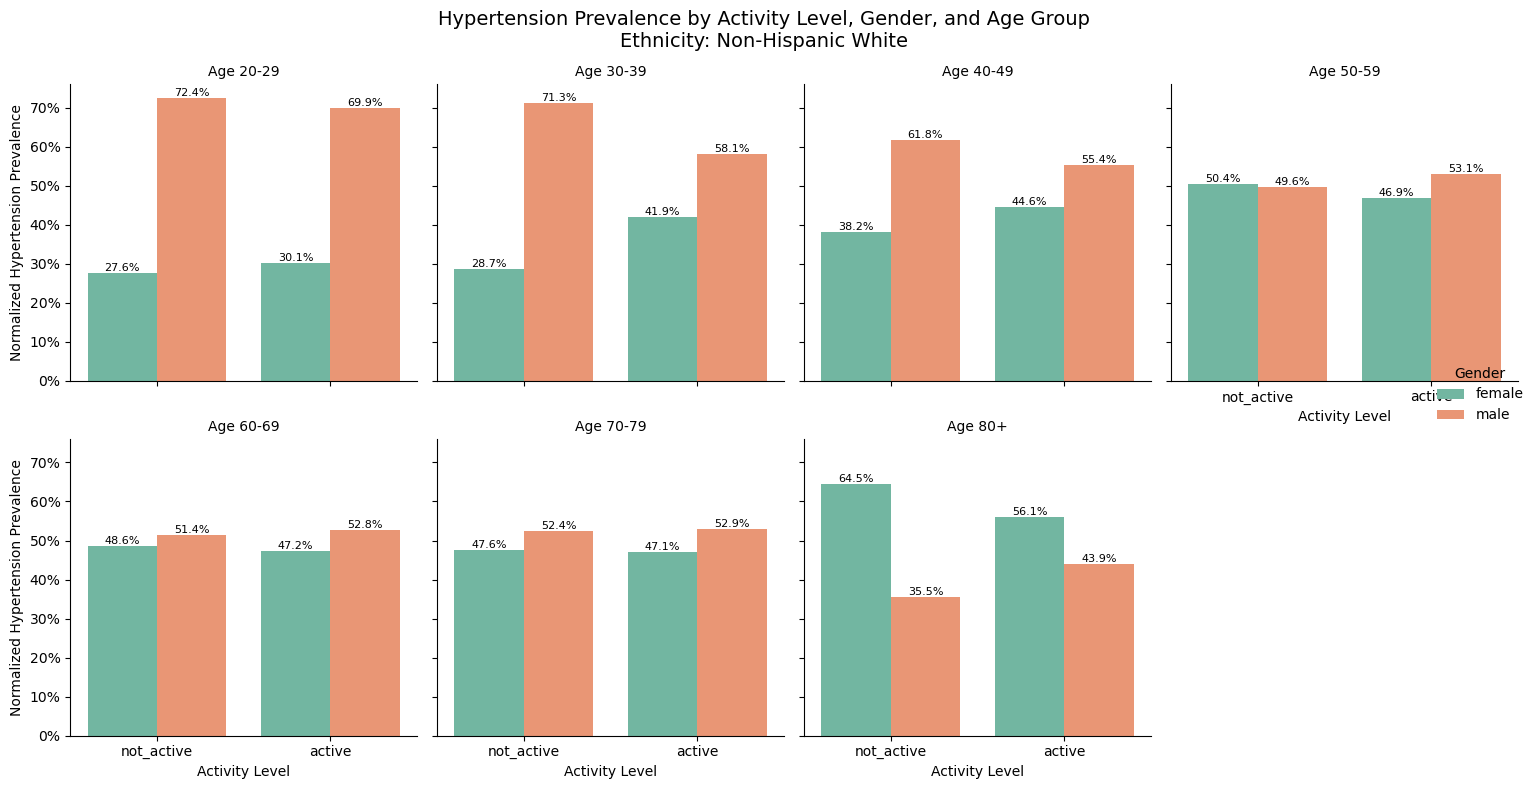

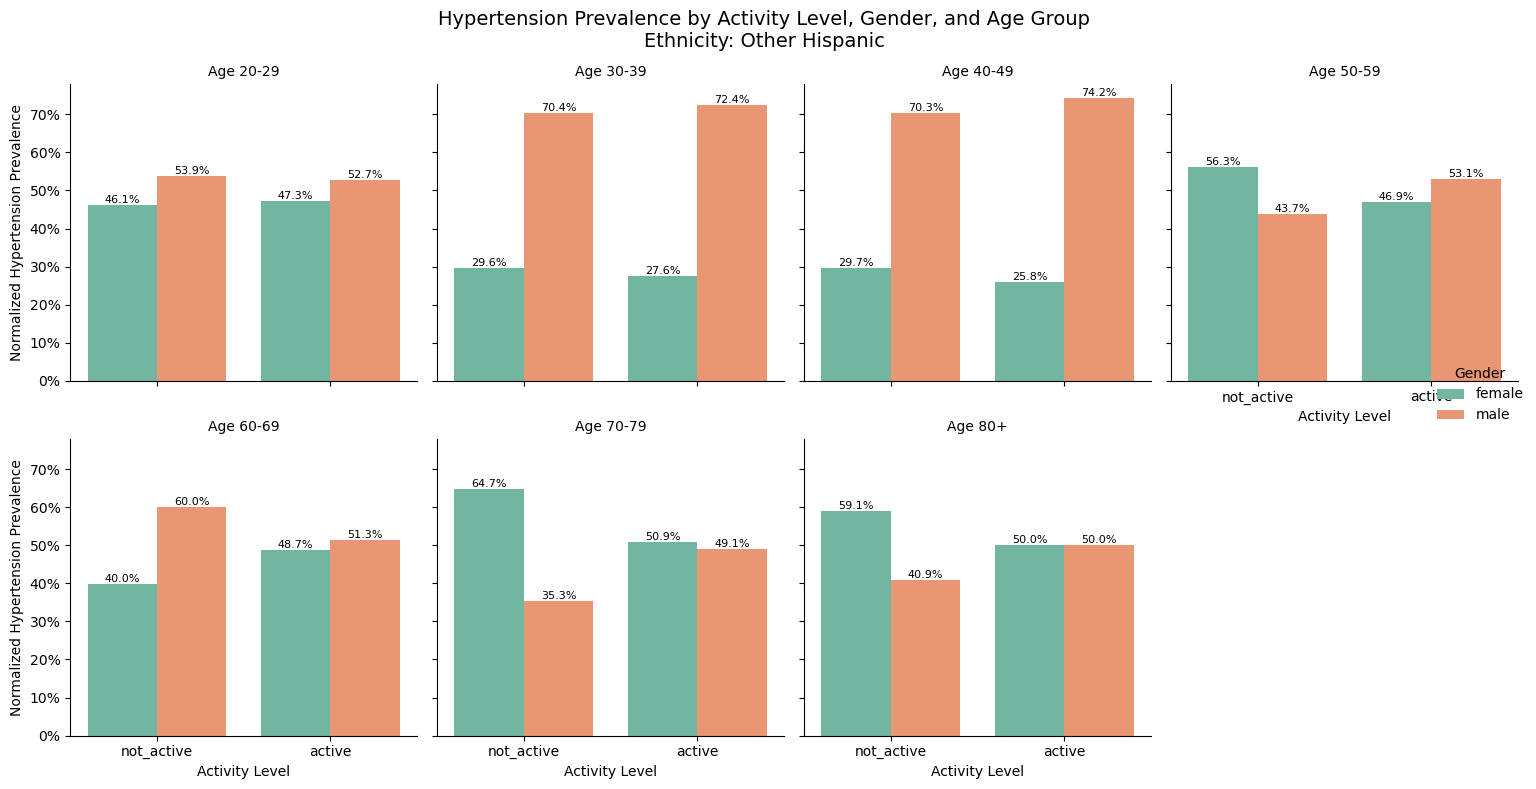

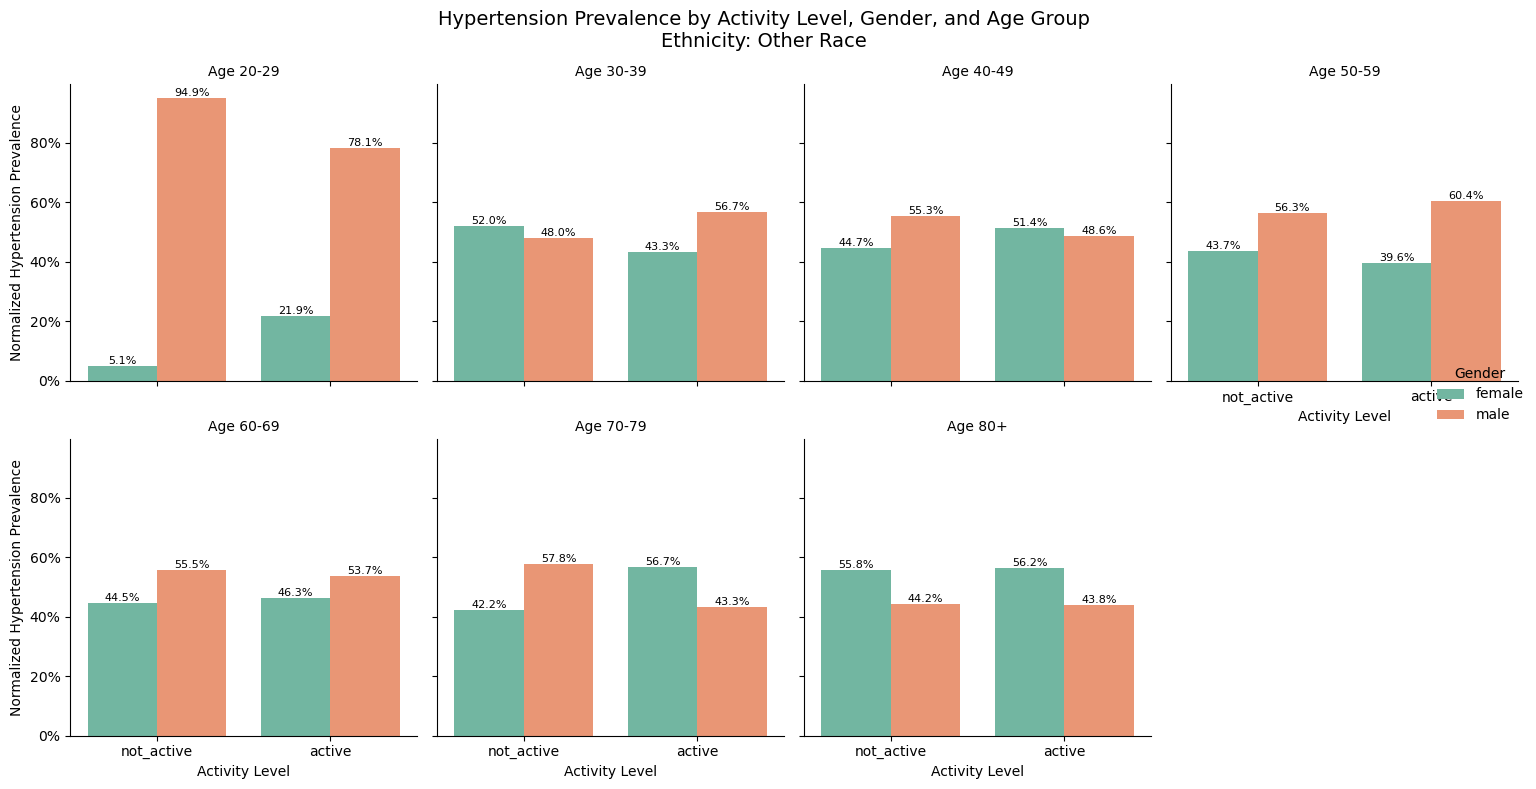

In [11]:
# ----------------------------
# STEP 1: Age Group Binning
# ----------------------------
age_bins = [20, 30, 40, 50, 60, 70, 80, np.inf]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df_filtered['Age_Group'] = pd.cut(df_filtered['Age_Years'], bins=age_bins, labels=age_labels, right=False)

# ----------------------------
# STEP 2: Compute Weighted Prevalence
# ----------------------------
grouped = df_filtered.groupby(['Age_Group', 'activity_level', 'Gender', 'Race_Ethnicity']) \
                     .apply(compute_weighted_ci).reset_index()

# ----------------------------
# STEP 3: Normalize Within Age_Group x activity_level x Ethnicity
# ----------------------------
grouped['total'] = grouped.groupby(['Age_Group', 'activity_level', 'Race_Ethnicity'])['Weighted_Hypertension_Prevalence'].transform('sum')
grouped['Normalized_Prevalence'] = grouped['Weighted_Hypertension_Prevalence'] / grouped['total']

# ----------------------------
# STEP 4: Clean Category Order
# ----------------------------
activity_order = ['not_active', 'active']
grouped['activity_level'] = pd.Categorical(grouped['activity_level'], categories=activity_order, ordered=True)
grouped['Age_Group'] = pd.Categorical(grouped['Age_Group'], categories=age_labels, ordered=True)

# ----------------------------
# STEP 5: Plot by Ethnicity
# ----------------------------
ethnicities = grouped['Race_Ethnicity'].unique()

for ethnicity in ethnicities:
    subset = grouped[grouped['Race_Ethnicity'] == ethnicity]

    g = sns.catplot(
        data=subset,
        kind='bar',
        x='activity_level',
        y='Normalized_Prevalence',
        hue='Gender',
        col='Age_Group',
        palette='Set2',
        height=4,
        aspect=0.9,
        sharey=True,
        col_wrap=4
    )

    # Add percentages on bars
    for ax in g.axes.flatten():
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        for container in ax.containers:
            labels = [f"{bar.get_height()*100:.1f}%" if bar.get_height() > 0 else "" for bar in container]
            ax.bar_label(container, labels=labels, label_type='edge', fontsize=8)

    g.set_titles(col_template="Age {col_name}")
    g.set_axis_labels("Activity Level", "Normalized Hypertension Prevalence")
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(f"Hypertension Prevalence by Activity Level, Gender, and Age Group\nEthnicity: {ethnicity}", fontsize=14)

    plt.tight_layout()
    plt.show()